In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


#warnings.formatwarning = custom_warning_format

### dstorm

In [46]:
def prepare_transition_set_ofret(number_fluorophores, distance):
    fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=distance, count=number_fluorophores, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

    transitions = fluorophore_system.load_transitions(
    summarize=True,
    irradiance=2.5,
    wavelength=640,
    bleaching=False,
    energy_transfer=True,
    dstorm=True,
    dstorm_parameters={'reducing_agent':'mea',
    'concentration':100,
    'ph':7.5},
    energy_transfer_parameters={'overwrite': {'off': [1, 0.0001]}, 
                                'exclude': ['s0']}
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()

    return transition_set


### Excitation rate calculation
2.5 kW/cm² was measured as the experimental irradiance. It is very likely that this was the average (can either be defined as for a very long time; or from pulse to pulse, including the interval in between with no laser emission). The laser pulses have a frequency of 80MHz, meaning within 1 s, there were 8e7 pulses, each with a duration of 50 ps (5e-11s). This means that during 1 s,  5e-11*8e7s = 4e-3s of irradiation happened. This means that the irradiance of a single pulse must have been 1/4e-3 times higher than the average. 

### 4F 3nm dSTORM

In [58]:
filepath = r"c:\Users\vie43sq\Desktop\Simulations\simulation_data\OET_lifetimes\4f_3nm_dstorm"
lifetimes_file = fr"{filepath}\lifetimes.npy"
event_time_series_file = fr"{filepath}\event_time_series.parquet"

transition_set = prepare_transition_set_ofret(4, 3)
rng = np.random.default_rng(42)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
Da, D, lifetimes_all = \
    emis.tcspc(transition_set, number_pulses=1e8, excitation_rates={'cy5_dna': 3.75e9},
               time_between_pulses=12.5e-9)

emis.event_time_series.to_frame().to_parquet(event_time_series_file)
np.save(lifetimes_file, lifetimes_all)

WARNING for line:     warnings.warn(
 the last frame (of index 1.25) has 0.00e+00 times the pulses of other frames. 


In [8]:
# filtering
rng = np.random.default_rng(42)
photon_collection_rate = fo.calculate_photon_collection_rate(
    NA=1.45, n1=1.51
)
emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
emis.add_transmittance(p=0.99, seed=rng) # lens 1
emis.add_transmittance(p=0.99, seed=rng) # lens 2
emis.add_quantum_efficiency(p=0.85, seed=rng)
emis.add_poisson_noise(rate=0.6, seed=rng)
emis.apply_threshold(threshold=10)

array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

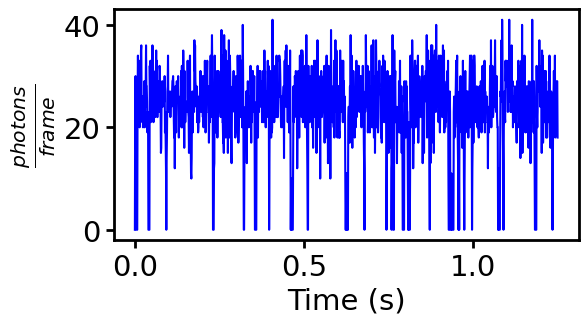

: 

In [ ]:
emis.plot_time_series()

array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

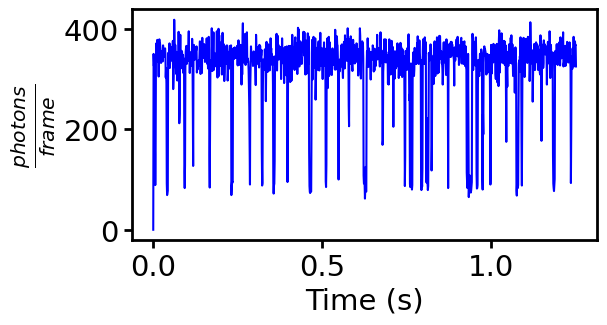

In [9]:
emis.plot_time_series()

### 4F 18nm dSTORM

In [56]:
filepath = r"c:\Users\vie43sq\Desktop\Simulations\simulation_data\OET_lifetimes\4f_18nm_dstorm"
lifetimes_file = fr"{filepath}\lifetimes.npy"
event_time_series_file = fr"{filepath}\event_time_series.parquet"

transition_set_18 = prepare_transition_set_ofret(4, 18)
rng = np.random.default_rng(42)
emis_18 = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
Da_18, D_18, lifetimes_all_18 = \
    emis_18.tcspc(transition_set_18, number_pulses=1e8, excitation_rates={'cy5_dna': 3.75e9},
               time_between_pulses=12.5e-9)

emis_18.event_time_series.to_frame().to_parquet(event_time_series_file)
np.save(lifetimes_file, lifetimes_all_18)

WARNING for line:     warnings.warn(
 the last frame (of index 1.25) has 0.00e+00 times the pulses of other frames. 


array([[<Axes: xlabel='Time (s)', ylabel='$\\frac{photons}{frame}$'>]],
      dtype=object)

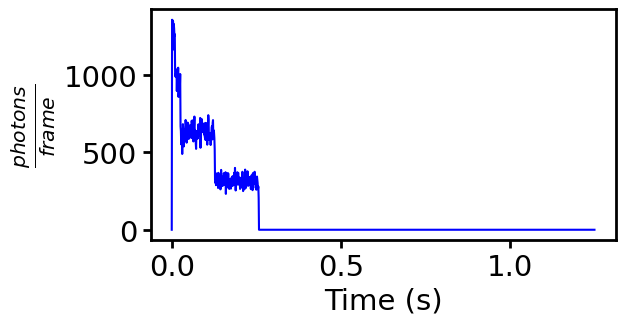

In [57]:
emis_18.plot_time_series()

### No dstorm

In [6]:
def prepare_transition_set_no_dstorm(number_fluorophores, distance):
    fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=distance, count=number_fluorophores, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

    transitions = fluorophore_system.load_transitions(
    summarize=True,
    irradiance=2.5,
    wavelength=640,
    bleaching=False,
    energy_transfer=True,
    dstorm=False,
    dstorm_parameters={'reducing_agent':'mea',
    'concentration':100,
    'ph':7.5},
    energy_transfer_parameters={'overwrite': {'off': [1, 0.0001]}, 
                                'exclude': ['s0']}
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()

    return transition_set

### 3 nm no dstorm

In [4]:
folder_path = r"c:\Users\vie43sq\Desktop\Simulations\simulation_data\OET_lifetimes\4f_3nm_no_dstorm"
lifetimes_file = fr"{folder_path}\lifetimes.npy"
event_time_series_file = fr"{folder_path}\event_time_series.parquet"

transition_set = prepare_transition_set_no_dstorm(4, 3)
rng = np.random.default_rng(42)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
Da, D, lifetimes_all = \
    emis.tcspc(transition_set, number_pulses=1e8, excitation_rates={'cy5_dna': 3.75e9},
               time_between_pulses=12.5e-9)

emis.event_time_series.to_frame().to_parquet(event_time_series_file)
np.save(lifetimes_file, lifetimes_all)

WARNING for line:     warnings.warn(
 the last frame (of index 1.25) has 0.00e+00 times the pulses of other frames. 


### 18 nm no dstorm

In [7]:
folder_path = r"c:\Users\vie43sq\Desktop\Simulations\simulation_data\OET_lifetimes\4f_18nm_no_dstorm"
lifetimes_file = fr"{folder_path}\lifetimes.npy"
event_time_series_file = fr"{folder_path}\event_time_series.parquet"

transition_set = prepare_transition_set_no_dstorm(4, 18)
rng = np.random.default_rng(42)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
Da, D, lifetimes_all = \
    emis.tcspc(transition_set, number_pulses=1e8, excitation_rates={'cy5_dna': 3.75e9},
               time_between_pulses=12.5e-9)

emis.event_time_series.to_frame().to_parquet(event_time_series_file)
np.save(lifetimes_file, lifetimes_all)

WARNING for line:     warnings.warn(
 the last frame (of index 1.25) has 0.00e+00 times the pulses of other frames. 


### 3 nm dstorm bleaching time series

In [2]:
def prepare_transition_set_ofret_bl(number_fluorophores, distance):
    fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=distance, count=number_fluorophores, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

    transitions = fluorophore_system.load_transitions(
    summarize=True,
    irradiance=2.5,
    wavelength=640,
    bleaching=True,
    energy_transfer=True,
    dstorm=False,
    dstorm_parameters={'reducing_agent':'mea',
    'concentration':100,
    'ph':7.5},
    energy_transfer_parameters={'overwrite': {'off': [1, 0.0001]}, 
                                'exclude': ['s0']}
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()

    return transition_set

In [52]:
transition_set.combined_state_transitions_df.iloc[27]

initial_state        (0, 0, 3, 0)
final_state          (0, 0, 3, 1)
fluorophore_ids               [3]
abbreviation                  EXC
transition_id                   0
rate               7269625.549132
photon                      False
Name: 27, dtype: object

In [53]:
# rng= efault_rng(42)
# number pulses = 1e8
# excitation rates = {'cy5_dna': 3.75e9}

In [64]:
transition_set.combined_state_transitions_df.iloc[sim.transition_series][200:215]

,initial_state,final_state,fluorophore_ids,abbreviation,transition_id,rate,photon
id,,,,,,,
4920,"(1, 0, 1, 0)","(0, 0, 1, 0)","[0, 2]",SSA,13,1.226198e+11,False
3001,"(0, 0, 1, 0)","(0, 0, 0, 0)",[2],S1S0SUM,6,4.245818e+08,False
3,"(0, 0, 0, 0)","(1, 0, 0, 0)",[0],EXC,0,7.269626e+06,False
3075,"(1, 0, 0, 0)","(0, 0, 0, 0)",[0],S1S0SUM,6,4.245818e+08,False
3,"(0, 0, 0, 0)","(1, 0, 0, 0)",[0],EXC,0,7.269626e+06,False
202,"(1, 0, 0, 0)","(1, 1, 0, 0)",[1],EXC,0,7.269626e+06,False
236,"(1, 1, 0, 0)","(1, 1, 1, 0)",[2],EXC,0,7.269626e+06,False
241,"(1, 1, 1, 0)","(1, 1, 1, 1)",[3],EXC,0,7.269626e+06,False
4950,"(1, 1, 1, 1)","(1, 0, 1, 1)","[1, 0]",SSA,13,1.226198e+11,False


In [57]:
sim.transition_series

array([   3, 3075,    3, 3075,    0, 3000,    2, 3010,    0,    5, 4903,
       3010,    3, 3075,    0, 3000,    3,  201, 4920, 3001,    0, 3000])

In [3]:
transition_set = prepare_transition_set_ofret_bl(4, 3)


In [5]:
import warnings

def block_all_warnings(*args, **kwargs):
    pass

warnings.showwarning = block_all_warnings

In [6]:
warnings.simplefilter('ignore')
filepath = r"c:\Users\vie43sq\Desktop\Simulations\simulation_data\OET_lifetimes\4f_3nm_dstorm_bl"
lifetimes_file = fr"{filepath}\lifetimes.npy"
event_time_series_file = fr"{filepath}\event_time_series.parquet"

#transition_set = prepare_transition_set_ofret_bl(4, 3)
rng = np.random.default_rng(42)
for rng in range(1000):
    emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
    Da, D, lifetimes_all, sim = \
        emis.tcspc(transition_set, number_pulses=1e2, excitation_rates={'cy5_dna': 3.75e10},
                time_between_pulses=12.5e-9, details=True)

# emis.event_time_series.to_frame().to_parquet(event_time_series_file)
# np.save(lifetimes_file, lifetimes_all)

In [ ]:
rng = np.random.default_rng(42)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
return_values = \
    emis.tcspc(transition_set, number_pulses=1e8, excitation_rates={'cy5_dna': 3.75e9},
            time_between_pulses=12.5e-9, details=True)